In [19]:
import pickle
from scipy.io import loadmat, savemat
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import MDS
import os

import pandas as pd
from mpl_toolkits.mplot3d import axes3d

import scipy

In [20]:
# dr = '/home/thomas/Desktop/MIT-projects/meta-motivo-features/data/test-mosaic/DTW-sm/'
# dr = '/home/thomas/Desktop/MIT-projects/meta-motivo-features/data/walk-run/DTW-sm/'
dr = '/home/thomas/Desktop/MIT-projects/meta-motivo-features/data/walk-run-antiphase-ext-res-36/' #DTW-sm/'

# Replace 'your_file.pkl' with the actual path to your pickle file
# file_path = dr + 'soft_dtw_dissimilarity.pkl'
# file_path = dr + 'soft_dtw_dissimilarity_walk_run_emd.pkl'
# file_path = dr + 'soft_dtw_dissimilarity_walk_run_gc_031026.pkl' #'soft_dtw_dissimilarity_walk_run_gc.pkl'
file_path = dr + 'soft_dtw_dissimilarity_walk_run_combined.pkl'

try:
    with open(file_path, 'rb') as file:
        sm_dtw = pickle.load(file)
    print("Pickle file loaded successfully!")
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except pickle.UnpicklingError as e:
    print(f"Error unpickling the file: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    

Pickle file loaded successfully!


<>:164: SyntaxWarning: invalid escape sequence '\g'
<>:164: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_87722/1936458045.py:164: SyntaxWarning: invalid escape sequence '\g'
  plt.title('$\gamma$ = ' + str(gs[0]))


error...


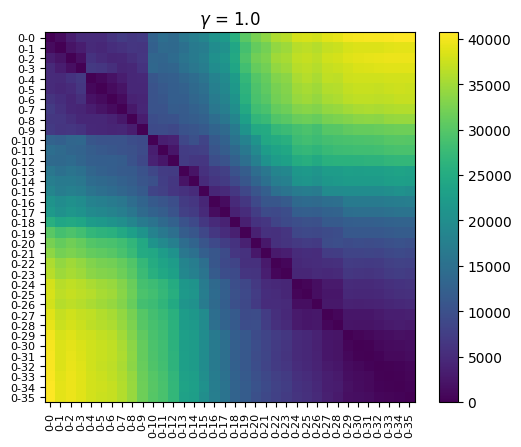

In [33]:
# ==> acceleration

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# dict = {
#     'fnames': [f.stem for f in files],
#     'qpos': {
#         'soft-dtw': {
            
#             'gamma': [],
#             'dissimilarity_mtx': []
#         },
#         'EMD': {
#             'dissimilarity_mtx': []
#         }
#     },
#     'qpos_gc': {
#         'soft-dtw': {
            
#             'gamma': [],
#             'dissimilarity_mtx': []
#         },
#         'EMD': {
#             'dissimilarity_mtx': []
#         }
#     },
#     'qvel': {
#         'soft-dtw': {
#             'gamma': [],
#             'dissimilarity_mtx': []
#         },
#         'EMD': {
#             'dissimilarity_mtx': []
#         }
#     },
#     'qvel_gc': {
#         'soft-dtw': {
#             'gamma': [],
#             'dissimilarity_mtx': []
#         },
#         'EMD': {
#             'dissimilarity_mtx': []
#         }
#     },
#     'qfrc_actuator': {
#         'soft-dtw': {
#             'gamma': [],
#             'dissimilarity_mtx': []
#         },
#         'EMD': {
#             'dissimilarity_mtx': []
#         }
#     },
#     'qfrc_actuator_gc': {
#         'soft-dtw': {
#             'gamma': [],
#             'dissimilarity_mtx': []
#         },
#         'EMD': {
#             'dissimilarity_mtx': []
#         }
#     },
#     'qpwr': {
#         'soft-dtw': {
#             'gamma': [],
#             'dissimilarity_mtx': []
#         },
#         'EMD': {
#             'dissimilarity_mtx': []
#         }
#     },
#     'qpwr_gc': {
#         'soft-dtw': {
#             'gamma': [],
#             'dissimilarity_mtx': []
#         },
#         'EMD': {
#             'dissimilarity_mtx': []
#         }
#     },
#     'gait_features': {
#         'cosine': []
#     }
# }
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# ==> features
# ==> somewhat related to kinematics
# f = 'qfrc_actuator' # torque
# ==> more closely related to energy
# f = 'qpwr'          # power

# ==> motion kinematics (proprioceptive information) --- feature 'f'
M_KINEMATICS = 'qvel' #'qpwr_gc'                   #'qpos' #'qvel' #'qfrc_actuator' #qpwr #'gait_features' #
# ==> EMD vs DTW... DTW can handle phase differences unlike euclidean distance. 
D_METRIC = 'soft-dtw'
# D_METRIC = 'EMD' #'cosine'
# ==> gamma index if applicable (gamma ranges from 0.0 tp 1.0 in increments of 0.2)
GAMMA_IDX = 5 #(0 -> 5)

# ==> parameters associated with mosaic...
reso = 36 #26 
# ==> alphas for interpolation
alphas = np.linspace(0.0,1.0,reso)
alphas = alphas[::-1]
# ==> resolution (in other dimension)
reso_v = 1
# ==> simplify... clean up these
m = reso
n = reso_v

# ==> read features
if D_METRIC == 'soft-dtw':
    gammas = sm_dtw[M_KINEMATICS][D_METRIC]['gamma']
    sm_dtws = sm_dtw[M_KINEMATICS][D_METRIC]['dissimilarity_mtx']

    # ==> ugly as sin...
    gammas_ = [float(f"{gammas[i]:.1f}") for i in range(len(gammas))]
    gammas = gammas_.copy()

if D_METRIC == 'cosine':
    gammas = [0] # ==> no gamma here
    sm_dtws = sm_dtw[M_KINEMATICS][D_METRIC]#['dissimilarity_mtx']
elif D_METRIC == 'EMD':
    gammas = [0] # ==> no gamma here
    sm_dtws = sm_dtw[M_KINEMATICS][D_METRIC]['dissimilarity_mtx']    

gammas_str = ['0.0','0.2','0.4','0.6','0.8','1.0']
# ==> the DASHBOARD files directory --- this will need to be flexible...
# ==> dashboard directory...
dshbdr = '/home/thomas/Desktop/mit-motivo-dashboard/files-wr-36' + '-'  + M_KINEMATICS + '-' + D_METRIC + '-' + gammas_str[GAMMA_IDX] + '/'

# ==> create dashboard folder directory
try:
    os.mkdir(dshbdr)
    os.mkdir(dshbdr + 'masks')
    os.mkdir(dshbdr + 'videos')
except:
    print('error...')

    # # ==> make directory for model if it doesn't exist...
    # try:
    #     os.mkdir(model_dr)

sms = []
gs  = []

# for g in range(len(gammas)):

# load dtw features and gamma value
if D_METRIC == 'cosine':
    sms.append(sm_dtws)
    gs.append(gammas)
if D_METRIC == 'soft-dtw':
    sms.append(sm_dtws[GAMMA_IDX])
    gs.append(gammas[GAMMA_IDX])
elif D_METRIC == 'EMD':
    sms.append(sm_dtws)
    gs.append(gammas)    
# # ==> normalize rows
# for i in range(sm.shape[0]):
#     sm[i,:] = sm[i,:] / np.sum(sm[i,:])
# ==> view
plt.imshow(sms[0])
plt.title('$\gamma$ = ' + str(gs[0]))
plt.xticks(ticks=np.arange(len(names)), labels=names, rotation=90, fontsize=8)
plt.yticks(ticks=np.arange(len(names)), labels=names, fontsize=8)
plt.colorbar()
plt.savefig('/home/thomas/Desktop/temp/' + M_KINEMATICS + '-' + D_METRIC + '-' + gammas_str[GAMMA_IDX] + '.png', dpi=600, format="png")
plt.show()


In [28]:
# '/home/thomas/Desktop/temp/' + M_KINEMATICS + '-' + D_METRIC + '-' + gammas_str[GAMMA_IDX] + '.png'

'/home/thomas/Desktop/temp/qvel-soft-dtw-1.0.png'

<>:49: SyntaxWarning: invalid escape sequence '\g'
<>:61: SyntaxWarning: invalid escape sequence '\g'
<>:49: SyntaxWarning: invalid escape sequence '\g'
<>:61: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_87722/636566568.py:49: SyntaxWarning: invalid escape sequence '\g'
  plt.title("MDS Visualization DTW for feature: " + M_KINEMATICS + ", $\gamma$ = " + str(gamma))
/tmp/ipykernel_87722/636566568.py:61: SyntaxWarning: invalid escape sequence '\g'
  plt.title("MDS Visualization DTW for feature: " + M_KINEMATICS + ", $\gamma$ = " + str(gamma))
/tmp/ipykernel_87722/636566568.py:47: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(proj[k,0],proj[k,1], c=clrs[k]/255)


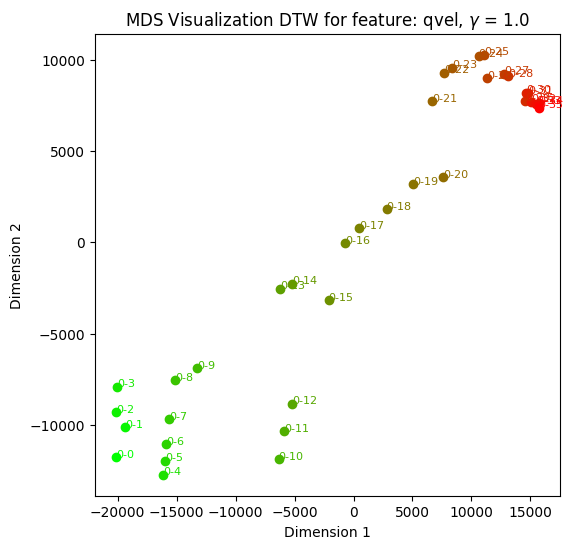

directory...
already exists
directory...
/home/thomas/Desktop/MIT-projects/meta-motivo-features/data/walk-run-antiphase-ext-res-36//qvel/soft-dtw/gamma-1.0/sm_qvel_gamma_1.0.mat
(1, 36, 2)
saved dtw_mds.npy...


In [36]:
sm = sms[0]
gamma = gs[0]


# g = len(gammas) - 1
# ==> mosaic parameters... ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
reso = 36 #26
# ==> alphas for interpolation
alphas = np.linspace(0.0,1.0,reso)
alphas = alphas[::-1]
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# ==> WHAT ARE THE DIMENSIONS OF THE SPECTRUM?
resoX = len(alphas)
resoY = 1
# ==> array dimensions / resolution (N x M)
arrwidth  = resoX
arrheight = resoY

def arr_creat(upperleft, upperright, lowerleft, lowerright):
    arr = np.linspace(np.linspace(lowerleft, lowerright, arrwidth), 
                      np.linspace(upperleft, upperright, arrwidth), arrheight, dtype=int)
    return arr[:, :, None]

rRGB = arr_creat(0,   255, 0,   255)
gRGB = arr_creat(0,   0,   255, 0)
bRGB = arr_creat(255, 255, 0,   0)
# ==> make a color gradient
cmask = np.concatenate([rRGB, gRGB, bRGB], axis=2)

# ==> append colors and names
clrs = []
names = []
for i in range(cmask.shape[0]):
    for j in range(cmask.shape[1]):
        clrs.append(cmask[i,j,:])
        names.append(str(i) + '-' + str(j))
        
# ==> MDS projection
d = 2
mds = MDS(n_components=d, dissimilarity='precomputed', random_state=0)
proj = embedding = mds.fit_transform(sm)

#==> plot
if d == 2:
    fig = plt.figure(figsize=(6, 6))
    for k in range(sm.shape[0]):
        plt.scatter(proj[k,0],proj[k,1], c=clrs[k]/255)
        plt.text(proj[k, 0], proj[k, 1], names[k],c=clrs[k]/255, size=8)
    plt.title("MDS Visualization DTW for feature: " + M_KINEMATICS + ", $\gamma$ = " + str(gamma))
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")  

if d == 3:
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')
    # ax.view_init(elev=30, azim=30, roll=0)
    ax.view_init(elev=30, azim=30, roll=30)
    for k in range(len(names)):
        ax.scatter3D(proj[k,0], proj[k,1], proj[k,2], c=clrs[k]/255)
        # ax.text(proj[k, 0], proj[k, 1], proj[k,2], names[k],c=clrs[k]/255, size=8)
    plt.title("MDS Visualization DTW for feature: " + M_KINEMATICS + ", $\gamma$ = " + str(gamma))
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.ylabel("Dimension 3")
plt.savefig('/home/thomas/Desktop/temp/' + M_KINEMATICS + '-' + D_METRIC + '-' + gammas_str[GAMMA_IDX] + '_mds_' + '.png', dpi=600, format="png")
plt.show()

# ==> load names (fix above mds plot cell - screws up names)
# ctx_dr = '/home/thomas/Desktop/effi-comp-verb-main/meta-motivo/spectra-ctx/walk-run-ctx/'
# try:
#     entries = os.listdir(ctx_dr)
#     names = [entry for entry in entries if os.path.isfile(os.path.join(ctx_dr, entry))]
#     print("Files in directory (os.listdir):")
# except FileNotFoundError:
#     print(f"Error: Directory not found at {ctx_dr}")
# print(names)
# ==> normalize rows (SAVE AS MEANING MATRIX FOR IB DIRECTLY)
# # ==> DTW sometimes has negative values
# sm_NORM_DTW = np.zeros((sms[g].shape[0],sms[g].shape[1]))
# for i in range(sm_NORM_DTW.shape[0]):
#     for j in range(sm_NORM_DTW.shape[1]):
#          # Soft-DTW(x, y) - (Soft-DTW(x, x) + Soft-DTW(y, y)) / 2
#         sm_NORM_DTW[i,j] = sms[g][i,j] - ( sms[g][i,i] + sms[g][j,j] ) / 2

# NORMALIZE ROWS?????
NORMALIZE_ROWS = False

sm_NORM_DTW = sms[0].copy()
assert(np.min(sm_NORM_DTW[:]) == 0.0)

# plt.imshow(sm_NORM_DTW)
# plt.title('sm norm DTW')
# plt.colorbar()
# plt.show()

sm = np.zeros((sms[0].shape[0],sms[0].shape[1]))
for i in range(sm.shape[0]):
    if NORMALIZE_ROWS:
        sm[i,:] = sm_NORM_DTW[i,:] / np.sum(sm_NORM_DTW[i,:]) 
    else:
        sm[i,:] = sm_NORM_DTW[i,:]
        
# if NORMALIZE_ROWS:
#     plt.imshow(sm)
#     plt.title('sm row-normalized for IB')
#     plt.colorbar()
#     plt.show()



try:
    os.mkdir(dr + M_KINEMATICS)
    os.mkdir(dr + M_KINEMATICS + '/soft-dtw/')
    os.mkdir(dr + M_KINEMATICS + '/soft-dtw/' + 'gamma-' + gammas[i] + '/')
    os.mkdir(dr + M_KINEMATICS + '/cosine/')
    os.mkdir(dr + M_KINEMATICS + '/cosine/' + 'gamma-' + gammas[i] + '/')
    os.mkdir(dr + M_KINEMATICS + '/EMD/')
    os.mkdir(dr + M_KINEMATICS + '/EMD/' + 'gamma-' + gammas[i] + '/')
except:
    print('directory...')
    
try:
    os.mkdir(dr + '/' + M_KINEMATICS + '/' + D_METRIC + '/' + 'gamma-' + str(gammas[GAMMA_IDX]) + '/')
except:
    print('already exists')
    
try:
    for i in range(gammas):
        os.mkdir(dr + M_KINEMATICS + '/soft-dtw/gamma-' + gammas[i] + '/')
except:
    print('directory...')
    

    
# ==> matlab format
mdic = {"proj": proj, "sm": sm, "labels": names}
savemat(dr + '/' + M_KINEMATICS + '/' + D_METRIC + '/' + 'gamma-' + str(gammas[GAMMA_IDX]) + '/' + 'sm' + '_' + M_KINEMATICS + '_' + 'gamma_' + str(gammas[GAMMA_IDX]) + '.mat', mdic)
# ==> sanity check...
print(dr + '/' + M_KINEMATICS + '/' + D_METRIC + '/' + 'gamma-' + str(gammas[GAMMA_IDX]) + '/' + 'sm' + '_' + M_KINEMATICS + '_' + 'gamma_' + str(gammas[GAMMA_IDX]) + '.mat')

# ==> could move this to motivo-load-features-sm notebook.
data_dict = {}
for i, na in enumerate(names):
    # ==> weird data flip with mds projection relative to grid mosaic appearance...
    data_dict[na] = proj[i,:] 
# ==> dtw_mds.npy – (m, n, 2) – [x,y] coordinate for feature (ex: dtw) for each thumbnail (i,j) in spectrum

# data = np.zeros((m,n,2))
data = np.zeros((n,m,2))
for _, na in enumerate(names):
    i = int(na.split('-')[0])
    j = int(na.split('-')[1].split('.mp4')[0]) #? .mp4 not in string
    # array type
    data[i,j,:] = data_dict[na]
print(data.shape)
np.save(dshbdr + 'dtw_mds.npy',data)
print('saved dtw_mds.npy...')

In [22]:
# sm
# names
# f
# plt.plot(data[:,:,0],data[:,:,1],'.')
# plt.show()
# names

In [2]:
# Human similarity

(36, 36, 222)
error - nan
error - nan
error - nan


/tmp/ipykernel_87722/3895426703.py:84: RuntimeWarning: Mean of empty slice
  sim_mu = np.nanmean(sim,2)


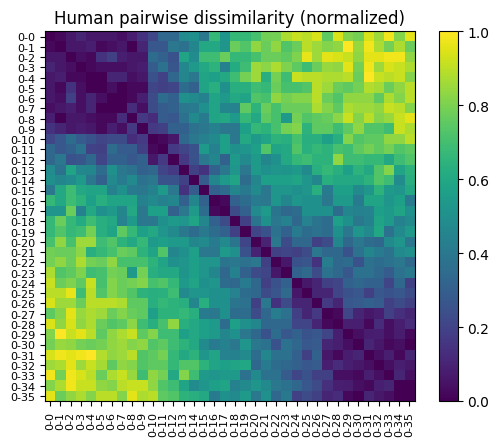

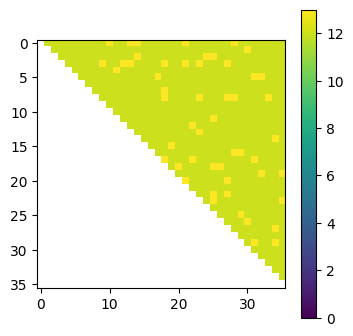

13.0


/tmp/ipykernel_87722/3895426703.py:178: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(proj[k,0],proj[k,1], c=clrs[k]/255)


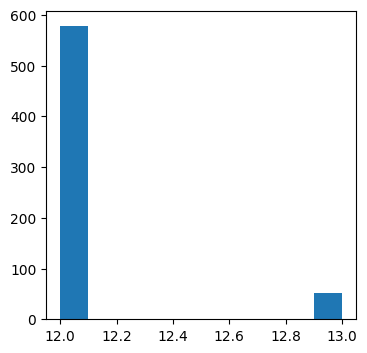

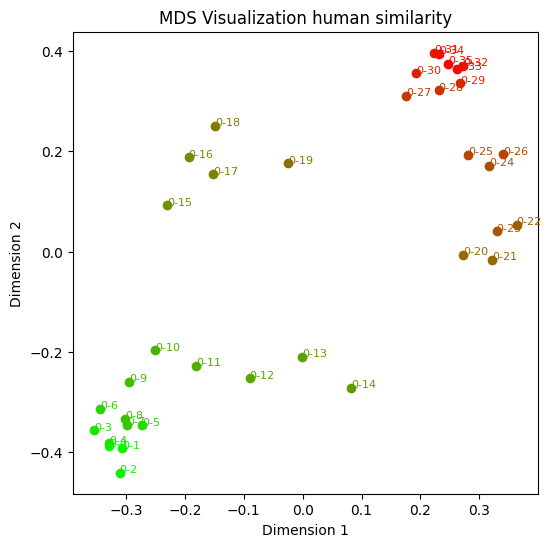

(1, 36, 2)
saved dtw_mds.npy...


In [18]:
# ==> HUMAN SIMILARITY

# ==> parameters associated with mosaic...
reso = 36 #26 
# ==> alphas for interpolation
alphas = np.linspace(0.0,1.0,reso)
alphas = alphas[::-1]
# ==> resolution (in other dimension)
reso_v = 1
# ==> simplify... clean up these
m = reso
n = reso_v

# ==> psynet prolific similarity
dr = '/home/thomas/Desktop/MIT-Experiments/prolific-data/motivo-walk-run-36-similarity/regular/data/'
# ==> file name
f = 'CustomTrial.csv'
# ==> load csv with pandas
df = pd.read_csv(dr + f)

# ==> participants and number of stimuli

# ==> parse participant ID
header_id = 'participant_id'
definition = 'definition'
answer = 'answer'
# ==> use pandas to extract numbers there (1 indexing, so ID = ID - 1)
# ID = ...
# IDs = <all IDs in the column>

# ==> participant IDs
IDs = df[header_id]
answers = df[answer]
stims = df[definition]

N = int(np.max(IDs)) # zero indexing
D = 36

# ==> initialize similarity matrix
sim = np.empty((D,D,N))
sim.fill(np.nan)
print(sim.shape)



for I in range(df.shape[0]):
    
    # ==> check for label ID practice or experiment
    if df['trial_maker_id'][I] == 'label_experiment':
        # ==> ID
        ID = int(IDs[I])
        
        # ==> parsing definition ========
        s = stims[I]
        s2 = s.split('{"name": "0-')[1]
        s3 = s2.split(".mp4")[0]
        # ==> indices
        i = int(s3.split("_0-")[0])
        j = int(s3.split("_0-")[1])
        # print(i,j)
        # ===============================
        
        # ==> parsing answer ============
        a = answers[I]
        try:
            ans = int(a.split(') ')[0][1])
        except:
            ans = np.nan
            print('error - nan')
        # print(ans)
        # ===============================
    
        # ==> for all answers (all rows in the dataframe), simply:
        sim[i,j,ID-1] = ans
    # else:
    #     print(df['trial_maker_id'][I])

# # ==> mode ===============================================
# sim_mu = scipy.stats.mode(sim, axis=2, nan_policy='omit')
# sim_mu = sim_mu[0]
# # ==> mode ===============================================

# ==> mean
sim_mu = np.nanmean(sim,2)

sim_muT = sim_mu.T

iu = np.triu_indices(D)
sim_muT[iu] = sim_mu[iu]

# ==> dissimilarity matrix
max_val = 6 # max similarity value
sim_mu = max_val - sim_mu

# ==> dissimilarity diagonal
sim_mu[np.isnan(sim_mu)] = 0

# ==> normalization
sim_n = sim_mu / np.max(sim_mu[:])

plt.imshow(sim_n)
plt.title('Human pairwise dissimilarity (normalized)')
plt.xticks(ticks=np.arange(len(names)), labels=names, rotation=90, fontsize=8)
plt.yticks(ticks=np.arange(len(names)), labels=names, fontsize=8)
plt.colorbar()
plt.savefig('/home/thomas/Desktop/temp/dissimilarity-prolific.png', dpi=600, format="png")
plt.show()

# ==> just count number of unique responses per pair... want a healthy number across all e.g. 10+
# sim_mu/np.max(sim_mu[:])

sim_counts = np.empty((D,D))
sim_counts.fill(np.nan)

for i in range(D):
    for j in range(D):
        if j > i:
            sim_counts[i,j] = np.sum(~np.isnan(sim[i,j,:]))

# counts_table = pd.DataFrame(sim_counts, columns=['stim-0-' + str(i) for i in range(D)])
# print(counts_table)
fig = plt.figure(figsize=(4, 4))
plt.imshow(sim_counts)
plt.colorbar()
plt.clim([0,np.nanmax(sim_counts[:])])
plt.show()

fig = plt.figure(figsize=(4, 4))
plt.hist(sim_counts[~np.isnan(sim_counts)])

sim_counts
print(np.nanmax(sim_counts[:]))

# g = len(gammas) - 1
# ==> mosaic parameters... ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
reso = D 
# ==> alphas for interpolation
alphas = np.linspace(0.0,1.0,reso)
alphas = alphas[::-1]
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# ==> WHAT ARE THE DIMENSIONS OF THE SPECTRUM?
resoX = len(alphas)
resoY = 1
# ==> array dimensions / resolution (N x M)
arrwidth  = resoX
arrheight = resoY

def arr_creat(upperleft, upperright, lowerleft, lowerright):
    arr = np.linspace(np.linspace(lowerleft, lowerright, arrwidth), 
                      np.linspace(upperleft, upperright, arrwidth), arrheight, dtype=int)
    return arr[:, :, None]

rRGB = arr_creat(0,   255, 0,   255)
gRGB = arr_creat(0,   0,   255, 0)
bRGB = arr_creat(255, 255, 0,   0)
# ==> make a color gradient
cmask = np.concatenate([rRGB, gRGB, bRGB], axis=2)

# ==> append colors and names
clrs = []
names = []
for i in range(cmask.shape[0]):
    for j in range(cmask.shape[1]):
        clrs.append(cmask[i,j,:])
        names.append(str(i) + '-' + str(j))

# ==> MDS projection
d = 2
mds = MDS(n_components=d, dissimilarity='precomputed', random_state=0)
proj = embedding = mds.fit_transform(sim_n)

angles = [-20,-10,0,10,20, 30,40,50,60,70]

#==> plot
if d == 2:
    fig = plt.figure(figsize=(6, 6))
    for k in range(D):
        plt.scatter(proj[k,0],proj[k,1], c=clrs[k]/255)
        plt.text(proj[k, 0], proj[k, 1], names[k],c=clrs[k]/255, size=8)
    plt.title("MDS Visualization human similarity")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")   
    plt.savefig('/home/thomas/Desktop/temp/dissimilarity-prolific-mds.png',dpi=600, format="png")
    plt.show()
if d == 3:
    for _, alpha in enumerate(angles):
        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection='3d')
        ax.view_init(elev=alpha, azim=15, roll=0)
        for k in range(len(names)):
            ax.scatter3D(proj[k,0], proj[k,1], proj[k,2], c=clrs[k]/255)
            ax.text(proj[k, 0], proj[k, 1], proj[k,2], names[k],c=clrs[k]/255, size=8)
        plt.title("MDS Visualization human similarity")
        plt.xlabel("Dimension 1")
        plt.ylabel("Dimension 2")
        plt.ylabel("Dimension 3")
        plt.savefig('/home/thomas/Desktop/temp/dissimilarity-prolific-mds.png',dpi=600, format="png")
    plt.show()

# ==> could move this to motivo-load-features-sm notebook.
data_dict = {}
for i, na in enumerate(names):
    # ==> weird data flip with mds projection relative to grid mosaic appearance...
    data_dict[na] = proj[i,:] 
# ==> dtw_mds.npy – (m, n, 2) – [x,y] coordinate for feature (ex: dtw) for each thumbnail (i,j) in spectrum

# data = np.zeros((m,n,2))
data = np.zeros((n,m,2))
for _, na in enumerate(names):
    i = int(na.split('-')[0])
    j = int(na.split('-')[1].split('.mp4')[0]) #? .mp4 not in string
    # array type
    data[i,j,:] = data_dict[na]
print(data.shape)
np.save('/home/thomas/Desktop/mit-motivo-dashboard/files-wr-36-prolific_similarity-cosine-0.0/' + 'dtw_mds.npy',data)
print('saved dtw_mds.npy...')


# ==> save human similarity
drs = '/home/thomas/Desktop/MIT-projects/meta-motivo-features/data/walk-run-antiphase-ext-res-36/prolific_similarity/cosine/gamma-0/'
fl = 'sm_prolific_similarity_gamma_0.mat'

mdic = {"sm": sim_n, "labels": names}
savemat(drs + fl, mdic)
